In [47]:
import os
import cv2
import torch
import numpy as np
import torchvision.transforms as T
import torchvision.models as models
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.transforms import functional as TF

In [48]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [49]:
# ── Paths: update these to your saved weight locations ────────────────────────
RCNN_WEIGHTS_PATH      = "E:/Github/Thyroid nodule detection/RCNN Model data/Best_wei/best_fasterrcnn.pth"
DENSENET_WEIGHTS_PATHS = [
    "E:/Github/Thyroid nodule detection/CNN Model data/Best models from 3Folds/best_densenet_fold1.pth",
    "E:/Github/Thyroid nodule detection/CNN Model data/Best models from 3Folds/best_densenet_fold2.pth",
    "E:/Github/Thyroid nodule detection/CNN Model data/Best models from 3Folds/best_densenet_fold3.pth",
]
RESNET_WEIGHTS_PATHS = [
    "E:/Github/Thyroid nodule detection/Resnet Model/Best Models/best_resnet50_fold1.pth",
    "E:/Github/Thyroid nodule detection/Resnet Model/Best Models/best_resnet50_fold2.pth",
    "E:/Github/Thyroid nodule detection/Resnet Model/Best Models/best_resnet50_fold3.pth",
]

# ── Preprocessing constants (IDENTICAL to training) ───────────────────────────
CLAHE_CLIP  = 2.0
CLAHE_GRID  = (8, 8)
CROP_MARGIN = 30
RESIZE_SIZE = 224

In [50]:
# ── Class labels ──────────────────────────────────────────────────────────────
CLASS_NAMES      = {0: "benign", 1: "malignant"}
RCNN_LABEL_NAMES = {1: "benign", 2: "malignant"}   # RCNN: 0=bg, 1=benign, 2=malignant
 
# ── Detection thresholds ──────────────────────────────────────────────────────
RCNN_SCORE_THRESH = 0.4
NMS_IOU_THRESH    = 0.3
MALIGNANT_THRESH  = 0.32

In [51]:
def apply_clahe(img_bgr):
    """CLAHE + unsharp mask -- identical to DenseNet & ResNet training."""
    lab       = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b   = cv2.split(lab)
    clahe     = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    l_clahe   = clahe.apply(l)
    img_clahe = cv2.cvtColor(cv2.merge([l_clahe, a, b]), cv2.COLOR_LAB2BGR)
    blurred   = cv2.GaussianBlur(img_clahe, (0, 0), sigmaX=2)
    sharpened = cv2.addWeighted(img_clahe, 1.3, blurred, -0.3, 0)
    return sharpened
 
 
def load_and_preprocess(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot open image: {image_path}")
    img_bgr = apply_clahe(img_bgr)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    return img_bgr, img_pil

In [52]:
def build_rcnn(num_classes=3):
    return fasterrcnn_resnet50_fpn_v2(weights=None, num_classes=num_classes)
 
 
def build_densenet():
    """Dropout(0.5) + Linear head -- matches training."""
    model = models.densenet121(weights=None)
    num_features     = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_features, 2)
    )
    return model
 
 
def build_resnet50():
    """Linear(2048->512)->ReLU->Dropout(0.3)->Linear(512->2) -- matches training."""
    model = models.resnet50(weights=None)
    num_features = model.fc.in_features   # 2048
    model.fc = nn.Sequential(
        nn.Linear(num_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, 2)
    )
    return model

In [53]:
def load_rcnn(weights_path):
    model = build_rcnn()
    model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    print(f"[RCNN]     Loaded: {weights_path}")
    return model
 
 
def load_densenet_ensemble(weights_paths):
    ensemble = []
    for path in weights_paths:
        m = build_densenet()
        m.load_state_dict(torch.load(path, map_location=DEVICE))
        m.to(DEVICE)
        m.eval()
        ensemble.append(m)
        print(f"[DenseNet] Loaded: {path}")
    return ensemble
 
 
def load_resnet_ensemble(weights_paths):
    ensemble = []
    for path in weights_paths:
        m = build_resnet50()
        m.load_state_dict(torch.load(path, map_location=DEVICE))
        m.to(DEVICE)
        m.eval()
        ensemble.append(m)
        print(f"[ResNet50] Loaded: {path}")
    return ensemble

In [54]:
val_transform = T.Compose([
    T.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
 
tta_transform = T.Compose([
    T.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    T.FiveCrop(int(RESIZE_SIZE * 0.9)),
    T.Lambda(lambda crops: torch.stack([
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])(T.ToTensor()(c))
        for c in crops
    ]))
])
 

In [55]:
def detect_nodules(rcnn_model, img_pil):
    tensor = TF.to_tensor(img_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        preds = rcnn_model(tensor)[0]
    boxes  = preds["boxes"].cpu()
    labels = preds["labels"].cpu()
    scores = preds["scores"].cpu()
    keep   = scores >= RCNN_SCORE_THRESH
    return boxes[keep], labels[keep], scores[keep]

In [56]:
def apply_nodule_nms(boxes, labels, scores):
    if len(boxes) == 0:
        return []
    order  = scores.argsort(descending=True)
    boxes  = boxes[order]
    labels = labels[order]
    scores = scores[order]
    kept   = []
    active = [True] * len(boxes)
    for i in range(len(boxes)):
        if not active[i]:
            continue
        kept.append((boxes[i], labels[i], scores[i]))
        for j in range(i + 1, len(boxes)):
            if not active[j]:
                continue
            iou = box_iou(boxes[i].unsqueeze(0), boxes[j].unsqueeze(0)).item()
            if iou >= NMS_IOU_THRESH:
                active[j] = False
    return kept

In [57]:
def crop_nodule(img_pil, box):
    W, H    = img_pil.size
    x1, y1, x2, y2 = map(int, box.tolist())
    x1 = max(0, x1 - CROP_MARGIN)
    y1 = max(0, y1 - CROP_MARGIN)
    x2 = min(W, x2 + CROP_MARGIN)
    y2 = min(H, y2 + CROP_MARGIN)
    return img_pil.crop((x1, y1, x2, y2)), (x1, y1, x2, y2)

In [58]:
def classify_crop(crop_pil, densenet_models, resnet_models):
    crop_rgb   = crop_pil.convert("RGB")
    probs_list = []
 
    # DenseNet x3: single pass
    tensor_dn = val_transform(crop_rgb).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        for m in densenet_models:
            out   = m(tensor_dn)
            probs = torch.softmax(out, dim=1)[0].cpu().numpy()
            probs_list.append(probs)
 
    # ResNet50 x3: 5-crop TTA
    tensor_rn = tta_transform(crop_rgb).to(DEVICE)   # (5, 3, H, W)
    with torch.no_grad():
        for m in resnet_models:
            out      = m(tensor_rn)
            probs_5  = torch.softmax(out, dim=1)
            avg_prob = probs_5.mean(dim=0).cpu().numpy()
            probs_list.append(avg_prob)
 
    # Average all 6
    avg_probs = np.mean(probs_list, axis=0)
    mal_prob  = float(avg_probs[1])
    cnn_label = "malignant" if mal_prob >= MALIGNANT_THRESH else "benign"
    return cnn_label, mal_prob, probs_list

In [59]:
def fuse_predictions(cnn_label, mal_prob, rcnn_label_int):
    rcnn_label = RCNN_LABEL_NAMES.get(rcnn_label_int, "unknown")
    agree      = (cnn_label == rcnn_label)
    if agree:
        return cnn_label, mal_prob, f"CNN+RCNN agree -> {cnn_label}"
    if 0.35 <= mal_prob <= 0.50:
        return rcnn_label, mal_prob, f"Marginal CNN ({mal_prob:.2f}), RCNN overrides -> {rcnn_label}"
    else:
        return cnn_label, mal_prob, f"CNN confident ({mal_prob:.2f}), overrides RCNN -> {cnn_label}"
 

In [60]:
BOX_COLORS = {"benign": (0, 220, 0), "malignant": (220, 0, 0)}
 
 
def draw_results(img_bgr, nodule_results):
    out = img_bgr.copy()
    for res in nodule_results:
        x1, y1, x2, y2 = res["box"]
        label  = res["final_label"]
        prob   = res["mal_prob"]
        color  = BOX_COLORS.get(label, (200, 200, 0))
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        conf  = prob if label == "malignant" else 1 - prob
        text  = f"{label.upper()}  {conf:.2f}"
        (tw, th), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
        ty    = max(y1 - 8, th + 4)
        cv2.rectangle(out, (x1, ty - th - 4), (x1 + tw + 4, ty + baseline), (0, 0, 0), -1)
        cv2.putText(out, text, (x1 + 2, ty - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2, cv2.LINE_AA)
    return out
 
 
def show_output(img_bgr, nodule_results, image_path):
    vis     = draw_results(img_bgr, nodule_results)
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(vis_rgb)
    ax.axis("off")
    notes = " | ".join([f"Nodule {i+1}: {r['note']}" for i, r in enumerate(nodule_results)])
    ax.set_title(notes, fontsize=9, wrap=True)
    from matplotlib.lines import Line2D
    legend = [
        Line2D([0],[0], color=(0, 220/255, 0), linewidth=2, label="Benign"),
        Line2D([0],[0], color=(220/255, 0, 0), linewidth=2, label="Malignant"),
    ]
    ax.legend(handles=legend, loc="upper right", fontsize=10)
    plt.suptitle(f"Thyroid Nodule Pipeline -- {os.path.basename(image_path)}", fontsize=12)
    plt.tight_layout()
    plt.show()
    return vis

In [61]:
def run_pipeline(image_path, rcnn_model, densenet_models, resnet_models,
                 save_path=None, verbose=True):
 
    img_bgr, img_pil = load_and_preprocess(image_path)
    W, H = img_pil.size
    if verbose:
        print(f"\n[Pipeline] Image: {image_path}  ({W}x{H})")
 
    boxes, labels, scores = detect_nodules(rcnn_model, img_pil)
    if verbose:
        print(f"[RCNN] Raw detections: {len(boxes)}")
        for i in range(len(boxes)):
            print(f"  box {i}: {boxes[i].tolist()}  "
                  f"label={RCNN_LABEL_NAMES.get(labels[i].item(),'?')}  "
                  f"score={scores[i].item():.3f}")
 
    if len(boxes) == 0:
        print("[Pipeline] No nodules detected above threshold. Stopping.")
        return []
 
    kept = apply_nodule_nms(boxes, labels, scores)
    if verbose:
        print(f"[NMS] Kept {len(kept)} nodule(s) after overlap handling")
 
    nodule_results = []
    for idx, (box, rcnn_label_t, score_t) in enumerate(kept):
        crop_pil, crop_coords          = crop_nodule(img_pil, box)
        cnn_label, mal_prob, per_model = classify_crop(crop_pil, densenet_models, resnet_models)
        rcnn_label_int                 = rcnn_label_t.item()
        final_label, mal_prob, note    = fuse_predictions(cnn_label, mal_prob, rcnn_label_int)
 
        if verbose:
            rcnn_name = RCNN_LABEL_NAMES.get(rcnn_label_int, "?")
            dn_probs  = [f"{p[1]:.3f}" for p in per_model[:3]]
            rn_probs  = [f"{p[1]:.3f}" for p in per_model[3:]]
            print(f"\n[Nodule {idx+1}]")
            print(f"  Box              : {crop_coords}")
            print(f"  RCNN label       : {rcnn_name}  (score={score_t.item():.3f})")
            print(f"  DenseNet mal_prob: {dn_probs}  (folds 1-3)")
            print(f"  ResNet50 mal_prob: {rn_probs}  (folds 1-3)")
            print(f"  Ensemble avg     : {mal_prob:.3f}")
            print(f"  CNN decision     : {cnn_label}")
            print(f"  Final decision   : {final_label.upper()}")
            print(f"  Note             : {note}")
 
        nodule_results.append({
            "box"        : crop_coords,
            "final_label": final_label,
            "mal_prob"   : mal_prob,
            "note"       : note,
        })
 
    vis = show_output(img_bgr, nodule_results, image_path)
 
    if save_path:
        cv2.imwrite(save_path, draw_results(img_bgr, nodule_results))
        print(f"\n[Pipeline] Output saved to: {save_path}")
 
    return nodule_results

Loading models...
[RCNN]     Loaded: E:/Github/Thyroid nodule detection/RCNN Model data/Best_wei/best_fasterrcnn.pth
[DenseNet] Loaded: E:/Github/Thyroid nodule detection/CNN Model data/Best models from 3Folds/best_densenet_fold1.pth
[DenseNet] Loaded: E:/Github/Thyroid nodule detection/CNN Model data/Best models from 3Folds/best_densenet_fold2.pth
[DenseNet] Loaded: E:/Github/Thyroid nodule detection/CNN Model data/Best models from 3Folds/best_densenet_fold3.pth
[ResNet50] Loaded: E:/Github/Thyroid nodule detection/Resnet Model/Best Models/best_resnet50_fold1.pth
[ResNet50] Loaded: E:/Github/Thyroid nodule detection/Resnet Model/Best Models/best_resnet50_fold2.pth
[ResNet50] Loaded: E:/Github/Thyroid nodule detection/Resnet Model/Best Models/best_resnet50_fold3.pth

All models ready.

[Pipeline] Image: E:\Github\Thyroid nodule detection\Data\000021.jpg  (498x429)
[RCNN] Raw detections: 1
  box 0: [210.9078369140625, 136.58798217773438, 291.422607421875, 203.04771423339844]  label=beni

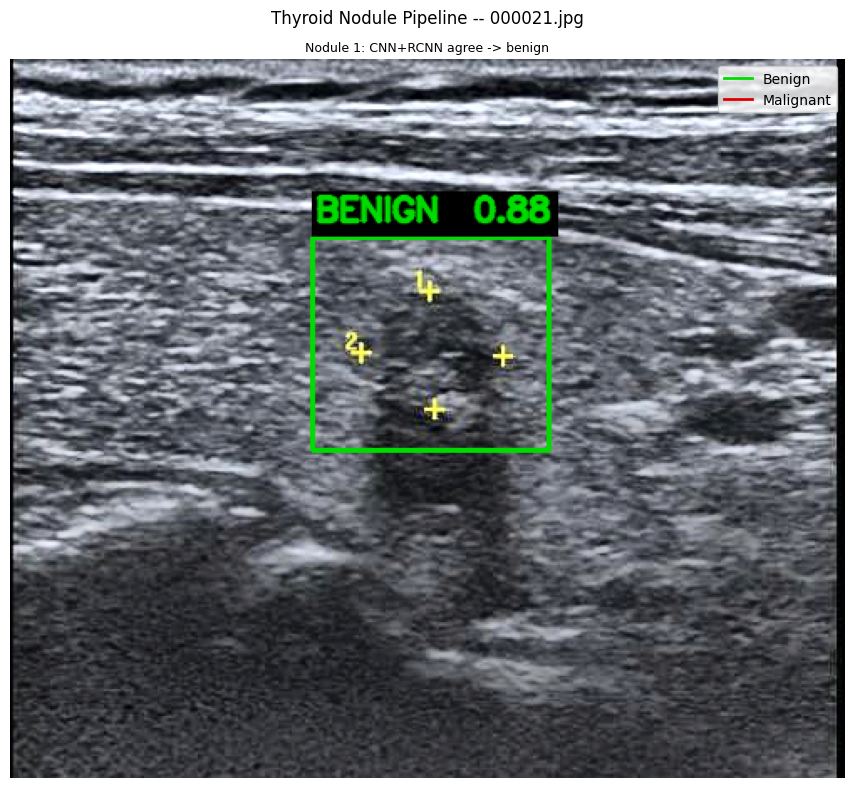


[Pipeline] Output saved to: E:\Github\Thyroid nodule detection\Data\000021_result.jpg


In [65]:
print("Loading models...")
rcnn_model      = load_rcnn(RCNN_WEIGHTS_PATH)
densenet_models = load_densenet_ensemble(DENSENET_WEIGHTS_PATHS)
resnet_models   = load_resnet_ensemble(RESNET_WEIGHTS_PATHS)
print("\nAll models ready.")
 
# Set your image path here
img_path = r"E:\Github\Thyroid nodule detection\Data\000021.jpg"   # <- change this
 
results = run_pipeline(
    image_path      = img_path,
    rcnn_model      = rcnn_model,
    densenet_models = densenet_models,
    resnet_models   = resnet_models,
    save_path       = img_path.replace(".jpg", "_result.jpg"),
    verbose         = True,
)